In [1]:
import pandas  as pd
import glob
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 400)

In [2]:
paths = glob.glob('/home/domingossj/Downloads/samudata/*.csv')

In [3]:
def format_hora_minuto(x):
    if pd.isna(x):
        return x
    try:
        pt1 = x.split(':')[0].zfill(2)
        pt2 = x.split(':')[1].zfill(2)
    except:
        import ipdb;ipdb.set_trace()
        
    return pt1 + ':' + pt2

df_all = pd.DataFrame()
for p in paths:
    df = pd.read_csv(p, sep=',', dtype=str)
    df['data'] = pd.to_datetime(df['data'])
    df['hora_minuto'] = df['hora_minuto'].apply(lambda x: format_hora_minuto(x))

    df['origem_chamado'] = df['origem_chamado'].replace(
        {'RESIDENCIAL': 'RESIDENC', 
         'VIA PÚBLICA':'VIA PUBL', 
         'UNIDADE DE SAÚDE': 'UNIDADE',
         'ANI / AL ': 'ANI/ALI '}
    )
    df_all =  pd.concat([df_all, df.drop_duplicates()])

In [4]:
df_all.head() # CASO SUSPEITO COVID-19 e COVID

,data,hora_minuto,municipio,bairro,endereco,origem_chamado,tipo,subtipo,sexo,idade,motivo_finalizacao,motivo_desfecho,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,2018-01-01,00:01,JABOATAO DOS GUARARAPES,PIEDADE,JOAO FRAGOSO DE MEDEIROS,RESIDENC,GASTROINTEST,HEMORDIGALTA,Masculino,26.0,NaN,Ocorrncia concluda com xito,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-01,00:09,LAGOA DO ITAENGA,NOVA ITAENGA,RODOVIA PAULO PETRIBU PE,VIA PUBL,EXTERNA,ACIDENTMOTO,Masculino,40.0,NaN,Ocorrncia concluda com xito,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-01-01,00:12,CONDADO,CENTRO,HOSPITAL JOAO PEREIRA DE ANDRADE,UNIDADE,GASTROINTEST,HEMORDIGALTA,Feminino,73.0,NaN,Paciente no necessita de remoo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-01-01,00:17,CABO DE SANTO AGOSTINHO,ENSEADAS DOS CORAIS,BEIRA MAR N 9 COND VILAGE MEDITERRANIO,VIA PUBL,EXTERNA,QUEDANIVEL,Feminino,52.0,NaN,Ocorrncia concluda com xito,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-01-01,00:23,RECIFE,IMBIRIBEIRA,DR. VALDI PESSOA N 36 A,RESIDENC,RESPIRATORIA,ASMA,Masculino,54.0,NaN,Ocorrncia concluda com xito,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df_all['municipio'].value_counts().head()

municipio
RECIFE                     635663
JABOATAO DOS GUARARAPES    184527
OLINDA                     132158
PAULISTA                   107152
CABO DE SANTO AGOSTINHO     50542
Name: count, dtype: int64

In [6]:
df_all['day'] = df_all['data'].dt.day
df_all['year'] = df_all['data'].dt.year
df_all['month'] = df_all['data'].dt.month

In [7]:
df_sample = df_all[(
    (~df_all['subtipo'].str.contains('COVID', case=True, na=False)) & 
    (~df_all['motivo_finalizacao'].str.contains('DUPLICADA', case=True, na=False))&
    #(df_all['municipio'].isin(['RECIFE'])) & 
    #(df_all['motivo_finalizacao'] == 'REGULAÇÃO POR TELEFONE') &
    (df_all['data']>='2022-06-01')
)].copy()

In [8]:
df_agg = df_sample.groupby('data')[['hora_minuto']].count()

In [9]:
df_agg = df_agg.reset_index()
df_joined = pd.DataFrame({'data': pd.date_range(df_agg['data'].min(), df_agg['data'].max(), freq='D')}
            ).merge(df_agg, on=['data'], how='left')# garantir que tem info todos os dias

<Axes: xlabel='data'>

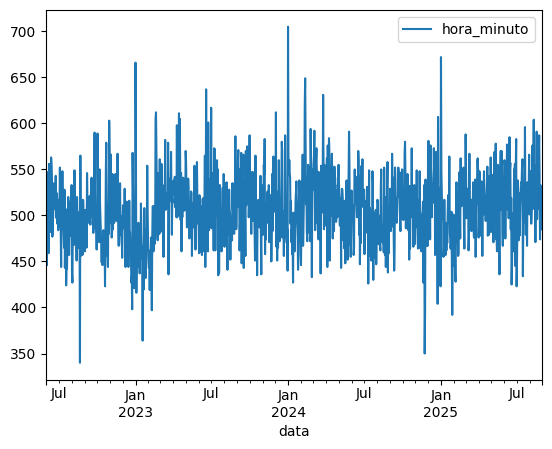

In [10]:
df_joined.set_index('data').plot()

In [25]:
df_mean = np.log(df_joined['hora_minuto'].rolling(window=7, min_periods=1).mean().iloc[7:])

<Axes: >

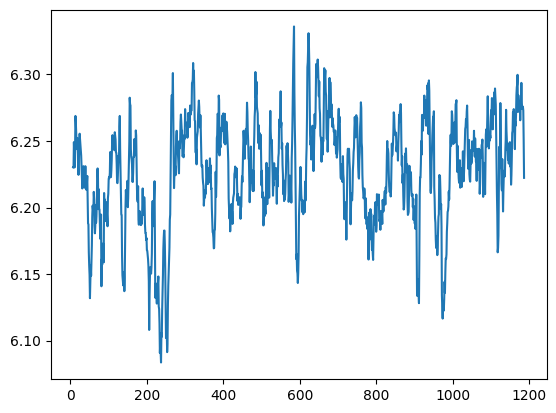

In [26]:
import numpy as np
df_mean.plot()

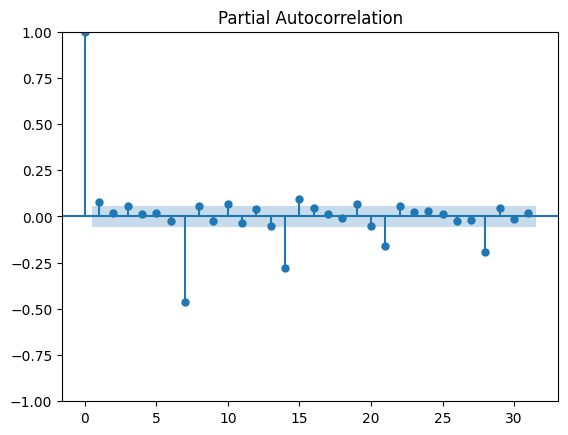

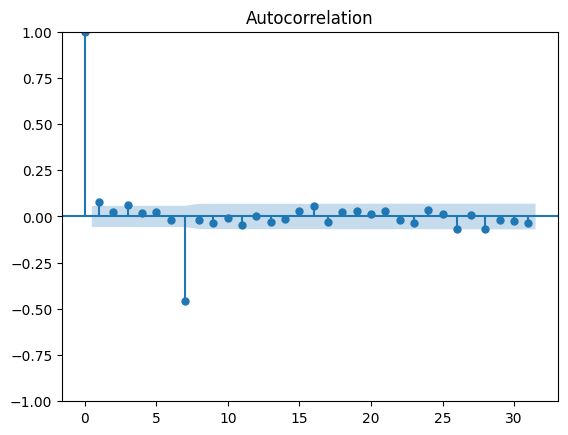

In [27]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
import matplotlib.pyplot as plt

plot_pacf(df_mean.diff().iloc[1:])
plt.show()
plot_acf(df_mean.diff().iloc[1:])
plt.show()

,hora_minuto
7,507.857143
8,507.714286
9,517.571429
10,513.142857
11,507.857143
...,...
1183,531.428571
1184,531.571429
1185,530.000000
1186,518.428571


In [41]:
pd.DataFrame(df_mean).rename(columns={'hora_minuto': 'y'})['y'].to_csv('masamu.txt', index=False)

In [16]:
df_joined.rename(columns={'hora_minuto': 'y'})['y'].to_csv('samurec.txt', index=False)

In [12]:
df_sample['motivo_finalizacao'].value_counts(dropna=False, normalize= True)

motivo_finalizacao
NaN                                                      0.713131
REGULAÇÃO POR TELEFONE                                   0.156112
DESISTÊNCIA DA SOLICITAÇÃO                               0.098620
REMOVIDO ANTES DO ATENDIMENTO POR PARTICULARES           0.024770
REMOVIDO PELOS BOMBEIROS/CIODS                           0.004342
PACIENTE JÉ ENCONTRADO EM ÓBITO                          0.002351
CANCELADA                                                0.000441
CANCELADA                                                0.000164
PACIENTE SEM CONDIÇÕES CLÍNICAS DE REMOÇÃO HOSPITALAR    0.000030
78                                                       0.000013
67                                                       0.000010
74                                                       0.000003
43                                                       0.000003
63                                                       0.000003
19                                                       

In [14]:
df_all[pd.isna(df_all['motivo_finalizacao'])]['motivo_desfecho'].value_counts()

motivo_desfecho
OCORRÊNCIA CONCLUÍDA COM ÊXITO                                  211658
1. OCORRÊNCIA CONCLUÍDA COM ÊXITO                               146571
Ocorrncia concluda com xito                                     127625
Ocorrência concluída com êxito                                   60015
Removido antes do atendimento por particulares                   43625
REMOVIDO ANTES DO ATENDIMENTO POR PARTICULARES                   38577
sem desfecho                                                     33133
PACIENTE RECUSA SER REMOVIDO                                     31107
5. REMOVIDO ANTES DO ATENDIMENTO POR PARTICULARES                30419
4. DESISTÊNCIA DA SOLICITAÇÃO/ SEM CONTATO COM O SOLICITANTE     27744
DESISTÊNCIA DA SOLICITAÇÃO                                       27096
Paciente recusa ser removido                                     24208
7. PACIENTE RECUSA SER REMOVIDO                                  19496
Desistncia da solicitao                                      